# CIFAR-10 Classification with PyTorch


## Introduction

The CIFAR-10 dataset is a collection of 60,000 32x32 color images, containing 10 object classes.

![cifar10](https://pytorch.org/tutorials/_static/img/cifar10.png)

## Environment Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os

In [2]:
np.random.seed(42)
torch.manual_seed(42)

# Determine the device (GPU if available, otherwise CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True # Choose the best algorithm according to hardware
    torch.cuda.manual_seed_all(42) # Initialize the seed for the GPU
else:
    device = torch.device("cpu")
    
print(f"\nUsing device: {device}")


num_workers = os.cpu_count() // 2 # Number of workers. Half of the available cores (common heuristic)


Using device: cpu


## Data Loading and Preparation

We will use the [official PyTorch tutorial for CIFAR-10 classification](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) as a baseline model and seek to improve its performance.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 'Lazy/Symmetric' Normalization with 0.5 for all channels
])

batch_size = 4

fulltrainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Separation into training and validation sets
train_size = int(0.8 * len(fulltrainset))
valid_size = len(fulltrainset) - train_size
trainset, validset = torch.utils.data.random_split(fulltrainset, [train_size, valid_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
validloader = torch.utils.data.DataLoader(validset, batch_size=batch_size, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

fulltrainset.classes # Classes are already defined in the dataset

100%|██████████| 170M/170M [01:02<00:00, 2.73MB/s] 
/Users/hugomaartinez/anaconda3/envs/ia/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

## Definition of Training and Validation Functions

There are different training and evaluation methodologies.
- Approach 1: Train completely, then evaluate (separate functions)
    - Simplicity: Simpler and easier to understand code.
    - Speed: Faster if you are only interested in the final result.
    - Less overhead: Does not interrupt the training process.
    - Suitable for large datasets: When evaluation is expensive.
- Approach 2: Evaluate after each epoch (integrated function)
    - Progress monitoring: You can see how the model improves during training.
    - Early detection of problems: Identify *overfitting/underfitting* in time.
    - *Early stopping*: You can stop training when it stops improving.
    - Saving the best model: Save the model with the best performance on validation.
    
In this case we use approach 2, which allows comparing different architectures by observing progress across epochs. Thus, we visualize not only the final results but also the learning curve.

Training and evaluation functions are defined so that they can be reused when training different architectures.

In [4]:
from utils.training_functions import train_model, evaluate_model, train_final_model
from utils.plot_functions import plot_metrics, plot_class_accuracy

## *Baseline*

Starting training on 'cpu' for 15 epochs with batch size 4...


Epoch 1/15 completed: Train Loss: 1.7670, Train Acc: 34.59%, Val Loss: 1.5558, Val Acc: 43.08%


Epoch 2/15 completed: Train Loss: 1.4260, Train Acc: 48.42%, Val Loss: 1.3405, Val Acc: 51.76%


Epoch 3/15 completed: Train Loss: 1.2784, Train Acc: 54.49%, Val Loss: 1.2273, Val Acc: 56.50%


Epoch 4/15 completed: Train Loss: 1.1759, Train Acc: 58.01%, Val Loss: 1.2187, Val Acc: 57.67%


...

Epoch 11/15 completed: Train Loss: 0.8214, Train Acc: 70.88%, Val Loss: 1.1824, Val Acc: 60.39%


Epoch 12/15 completed: Train Loss: 0.7943, Train Acc: 71.72%, Val Loss: 1.2344, Val Acc: 60.47%


Epoch 13/15 completed: Train Loss: 0.7619, Train Acc: 72.89%, Val Loss: 1.2640, Val Acc: 60.03%


Epoch 14/15 completed: Train Loss: 0.7440, Train Acc: 73.63%, Val Loss: 1.2573, Val Acc: 61.00%


Epoch 15/15 completed: Train Loss: 0.7253, Train Acc: 74.51%, Val Loss: 1.3245, Val Acc: 60.94%

Training completed after finishing all epochs.
Total training time: 1289.05 seconds


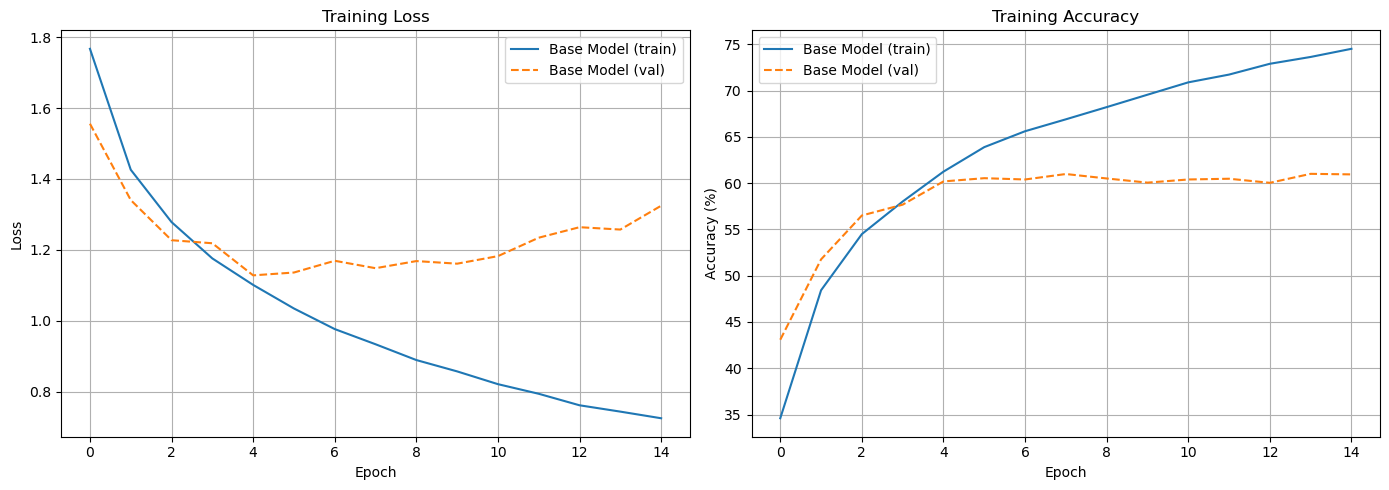

In [5]:
# Initialize the baseline model
from models.baseline import Net
base_model = Net()

# Define loss criterion and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(base_model.parameters(), lr=0.001, momentum=0.9)

# Train the baseline model
base_metrics = train_model(
    base_model, 
    trainset,
    validset,
    batch_size,
    criterion,
    optimizer,
    epochs=15,
    device=device,
    num_workers=num_workers
)

plot_metrics([base_metrics], ['Base Model'])

We can observe *overfitting* as the training accuracy increases much more than the validation accuracy starting from around epoch 10.

## Improvement

To avoid *overfitting*, we can use regularization, dropout, etc.

Starting training on 'cpu' for 15 epochs with batch size 32...


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1/15 completed: Train Loss: 1.5038, Train Acc: 44.88%, Val Loss: 1.1373, Val Acc: 58.22%


Epoch 2/15 completed: Train Loss: 1.1371, Train Acc: 59.88%, Val Loss: 0.9150, Val Acc: 67.83%


Epoch 3/15 completed: Train Loss: 0.9695, Train Acc: 66.40%, Val Loss: 0.8219, Val Acc: 70.79%


...

Epoch 11/15 completed: Train Loss: 0.4779, Train Acc: 83.60%, Val Loss: 0.6189, Val Acc: 79.55%


Epoch 12/15 completed: Train Loss: 0.4445, Train Acc: 84.66%, Val Loss: 0.5971, Val Acc: 80.22%


Epoch 13/15 completed: Train Loss: 0.4168, Train Acc: 85.66%, Val Loss: 0.5708, Val Acc: 81.56%


Epoch 14/15 completed: Train Loss: 0.3886, Train Acc: 86.66%, Val Loss: 0.6083, Val Acc: 80.85%


Epoch 15/15 completed: Train Loss: 0.3669, Train Acc: 87.20%, Val Loss: 0.6041, Val Acc: 81.75%

Training completed after finishing all epochs.
Total training time: 9434.31 seconds


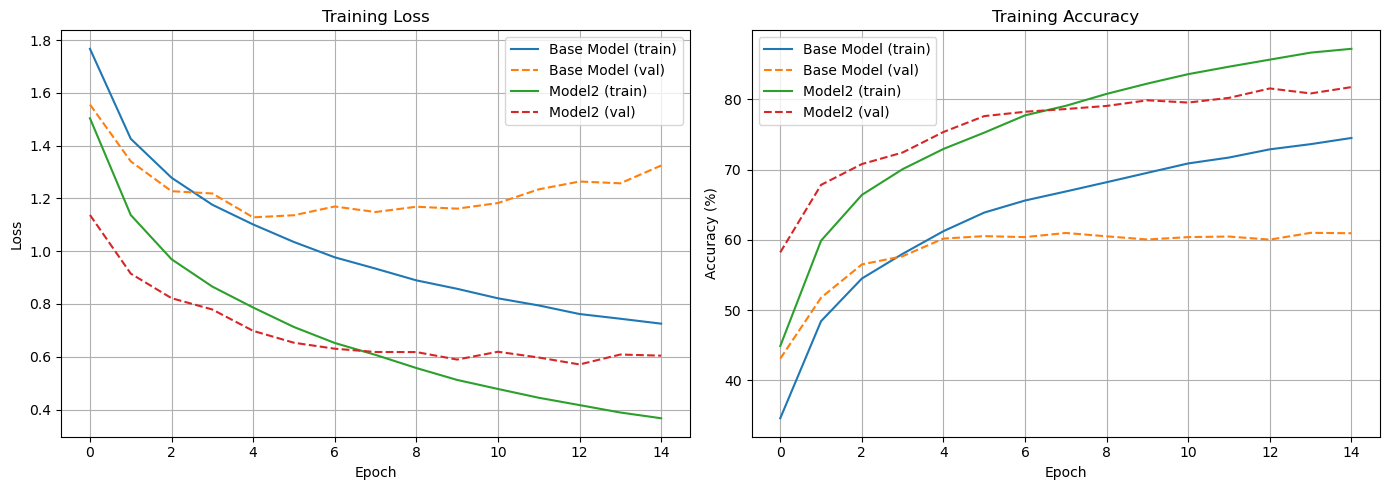

In [6]:
from models.mejorado import ImprovedCNN
model2 = ImprovedCNN()

# Define loss criterion and optimizer
criterion = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model2.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.AdamW(model2.parameters(), lr=0.001, weight_decay=1e-4)

# Train the model
metrics2 = train_model(
    model2, 
    trainset,
    validset,
    32,
    criterion,
    optimizer,
    epochs=15,
    device=device,
    num_workers=num_workers
)

### Visualization of metrics
plot_metrics([base_metrics, metrics2], ['Base Model', "Model2"])

## Test Evaluation and Storing the Final Model

Having chosen the newly proposed architecture as the final model, we retrain it with the entire training set.

In [7]:
model2 = ImprovedCNN() # Reinitialize the model (although there could be other strategies)
optimizer = torch.optim.AdamW(model2.parameters(), lr=0.001, weight_decay=1e-4)

final_metrics = train_final_model(
    model2,
    fulltrainset,
    batch_size,
    criterion,
    optimizer,
    epochs=10, # From here on we saw that overfitting began to occur
    device=device,
    num_workers=num_workers,
)

Starting final training on 'cpu' for 10 epochs with batch size 4...


Epoch 1/10 => Train Loss: 1.6597, Train Acc: 39.4940


KeyboardInterrupt: 

Test Loss: 0.5603, Test Accuracy: 81.75%


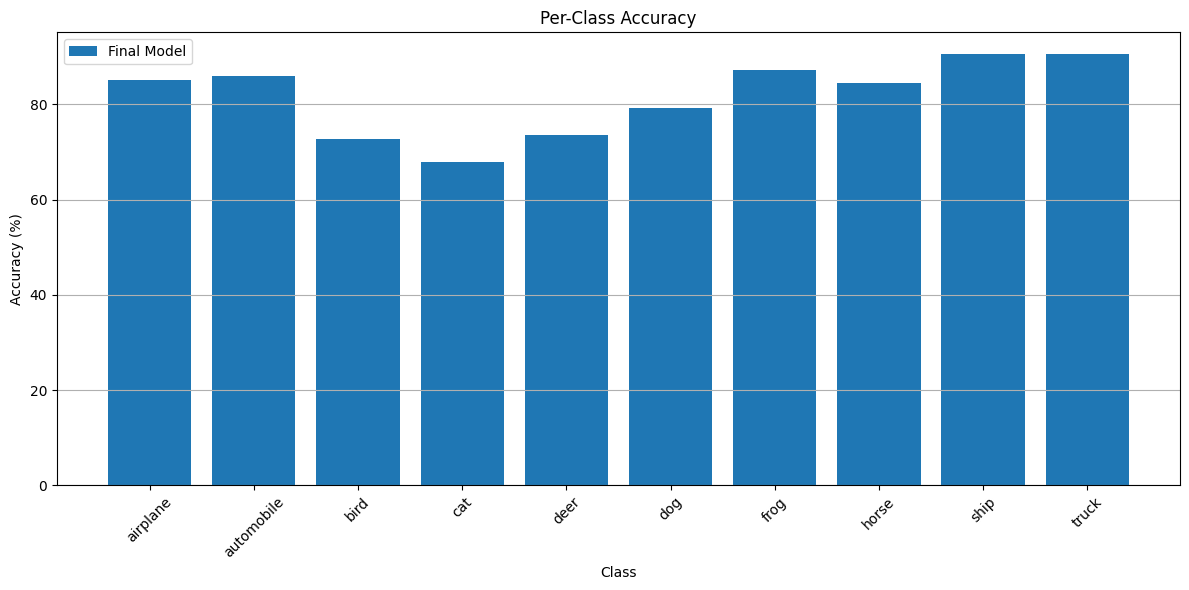

In [ ]:
# Evaluate the final model on the test set
test_results = evaluate_model(model2, testloader, criterion, device) # Capture the full results
test_loss = test_results['loss']
test_acc = test_results['accuracy']
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Now plot the class accuracy using the captured results
plot_class_accuracy(
    results_list=[test_results],  # Pass the results dictionary in a list
    model_names=['Final Model'],  # Provide a name for the model
    class_names=testset.classes
)

Once the model is chosen and trained, we can store it for deployment.

In [ ]:
PATH = './cifar_net.pth'
torch.save(model2.state_dict(), PATH)

## Deploy Model to Hugging Face Hub

Finally, we can automate the uploading of the trained model to the Hugging Face Model Hub. This allows our FastAPI application (running in Hugging Face Spaces) to download the latest model weights dynamically.

> **Authentication Requirement**: 
> To upload models to Hugging Face, you need an Access Token with **WRITE** permissions. 
> You have two secure options to provide this token:
> 1. **`.env` file**: Create a `.env` file in the base folder and add `HF_TOKEN=your_token_here`. Then restart your environment, or just export it in your shell (`export HF_TOKEN=...`).
> 2. **Interactive Login**: Use `huggingface_hub.notebook_login()` to paste your token interactively.

In [ ]:
import os
from huggingface_hub import HfApi, notebook_login

# Look for HF_TOKEN in environment variables
hf_token = os.environ.get("HF_TOKEN")

if not hf_token:
    print("HF_TOKEN not found in environment variables. Please login interactively:")
    notebook_login()
else:
    print("HF_TOKEN found in environment variables!")

HF_TOKEN not found in environment variables. Please login interactively:


In [ ]:
api = HfApi()

repo_id = "avidaldo/cifar-10-fastapi-model" # Target Model repo on Hugging Face

# Create the model repository if it doesn't exist
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

# Upload the model file
print(f"Uploading ./cifar_net.pth to {repo_id}...")
api.upload_file(
    path_or_fileobj='./cifar_net.pth',
    path_in_repo="cifar_net.pth",
    repo_id=repo_id,
    repo_type="model"
)

print(f"Model successfully uploaded to https://huggingface.co/{repo_id}")

Uploading ./cifar_net.pth to avidaldo/cifar-10-fastapi-model...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model successfully uploaded to https://huggingface.co/avidaldo/cifar-10-fastapi-model
